Members: 

RATCHAPON PARATAGO - 6837935

PANSOON LUANGTHONGKAM - 6836910

Project Link: https://github.com/ratchapon-p/ITCY583-Network-IDS

Install libs

In [ ]:
pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import Lib

In [2]:
import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")


Libraries loaded!


Load Data

In [3]:
path = r"C:\Users/user1/Desktop/DATASCIENCE_PROJECT/OwnLab\MachineLearningCVE\*.csv"
files = glob.glob(path)

df = pd.concat(
    [pd.read_csv(f, encoding='utf-8', low_memory=False) for f in files],
    ignore_index=True
)

# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
print(f"Files loaded: {len(files)}")

Shape: (2830743, 79)
Files loaded: 8


Handle Inf values

In [4]:
# Replace Inf with NaN first
df.replace([np.inf, -np.inf], np.nan, inplace=True)

inf_replaced = df.isnull().sum().sum()
print(f"Total NaN after replacing Inf: {inf_replaced}")

Total NaN after replacing Inf: 5734


Handle missing values

In [5]:
# Fill NaN with median (numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values remaining: 0


Drop zero-variance columns

In [6]:
zero_cols = [col for col in numeric_cols if df[col].max() == 0]
df.drop(columns=zero_cols, inplace=True)

print(f"Dropped {len(zero_cols)} zero-variance columns:")
print(zero_cols)
print(f"New shape: {df.shape}")

Dropped 8 zero-variance columns:
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
New shape: (2830743, 71)


Encode labels

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

Label mapping:
  0: BENIGN
  1: Bot
  2: DDoS
  3: DoS GoldenEye
  4: DoS Hulk
  5: DoS Slowhttptest
  6: DoS slowloris
  7: FTP-Patator
  8: Heartbleed
  9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS


Train/test split

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Label', 'Label_encoded'])
y = df['Label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (2264594, 70)
Test size:  (566149, 70)


Normalize

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Scaling done!
X_train_scaled shape: (2264594, 70)


SMOTE

In [15]:
from imblearn.over_sampling import SMOTE

# determine minimum 1000 samples per class
counts = pd.Series(y_train).value_counts()
strategy = {
    cls: max(count, 1000) 
    for cls, count in counts.items()
}

smote = SMOTE(sampling_strategy=strategy, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {X_train_scaled.shape}")
print(f"After SMOTE:  {X_train_sm.shape}")
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts().sort_index())

Before SMOTE: (2264594, 70)
After SMOTE:  (2268017, 70)

Class distribution after SMOTE:
Label_encoded
0     1818477
1        1573
2      102421
3        8234
4      184858
5        4399
6        4637
7        6350
8        1000
9        1000
10     127144
11       4718
12       1206
13       1000
14       1000
Name: count, dtype: int64


Eda class distribution

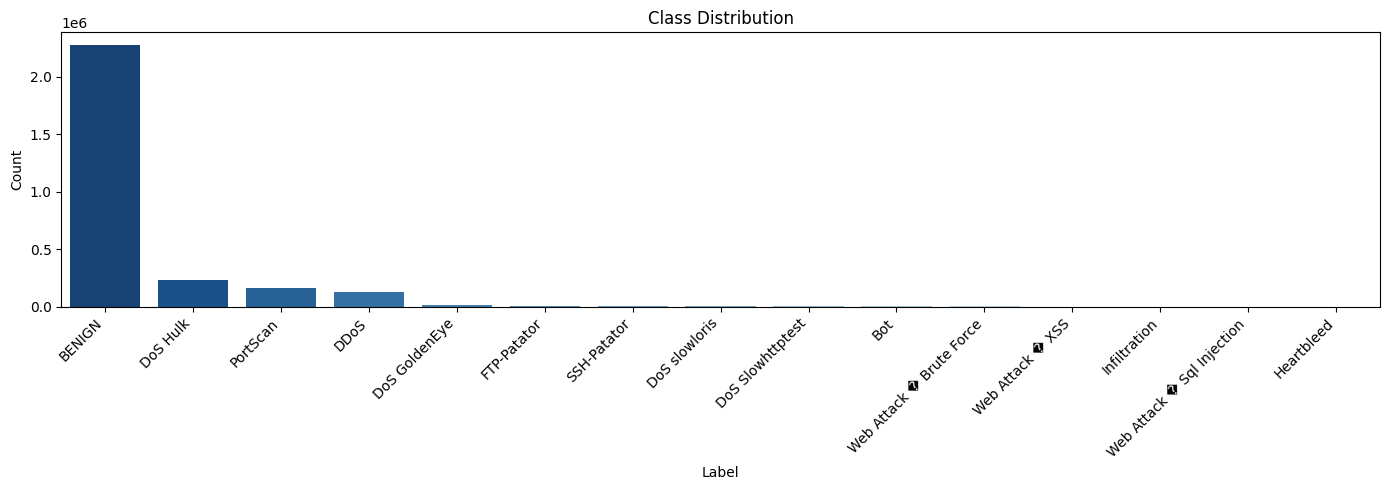

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = df['Label'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_r')
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

Correlation heatmap

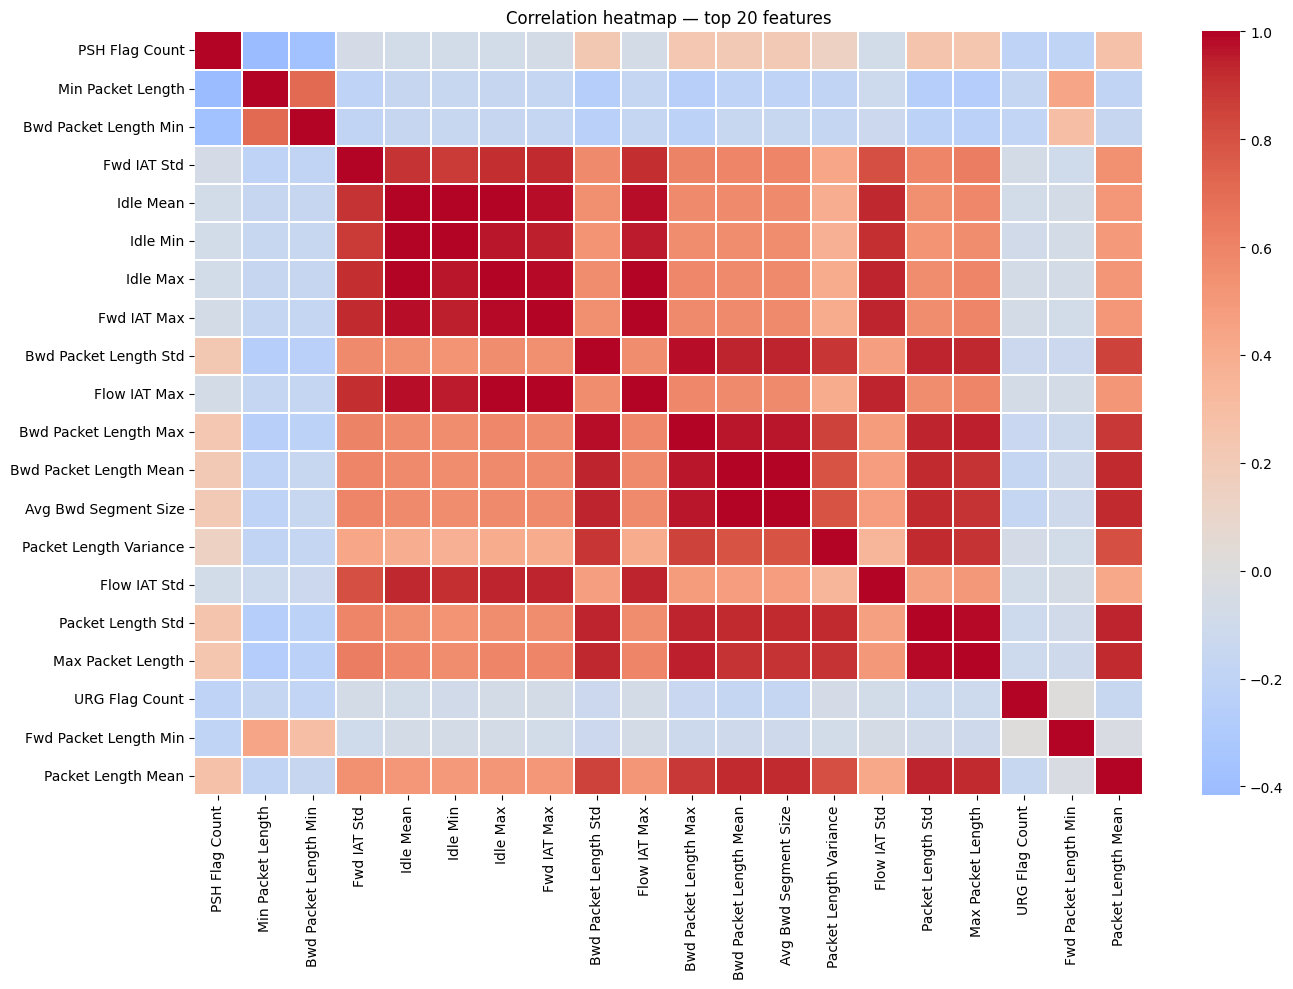

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['Label_encoded'].abs().sort_values(ascending=False)
top20 = corr[1:21].index

plt.figure(figsize=(14, 10))
sns.heatmap(
    df[top20].corr(),
    cmap='coolwarm', center=0,
    annot=False, linewidths=0.3
)
plt.title('Correlation heatmap — top 20 features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

RQ1: Kruskal-Wallis test

Analyze key network traffic features to determine which technical indicators most strongly influence cyberattack detection.

In [13]:
from scipy import stats

top10 = corr[1:11].index
results_kw = []

for feat in top10:
    groups = [df[df['Label_encoded'] == cls][feat].values
              for cls in df['Label_encoded'].unique()]
    stat, p = stats.kruskal(*groups)
    results_kw.append({
        'feature': feat,
        'statistic': round(stat, 2),
        'p_value': p,
        'significant': 'Yes' if p < 0.05 else 'No'
    })

kw_df = pd.DataFrame(results_kw).sort_values('statistic', ascending=False)
print("=== RQ1: Kruskal-Wallis Test Results ===")
print(kw_df.to_string(index=False))

=== RQ1: Kruskal-Wallis Test Results ===
              feature  statistic  p_value significant
          Fwd IAT Max  628318.19      0.0         Yes
Bwd Packet Length Std  557745.69      0.0         Yes
          Fwd IAT Std  536955.57      0.0         Yes
       PSH Flag Count  493140.08      0.0         Yes
             Idle Max  490869.78      0.0         Yes
            Idle Mean  489877.52      0.0         Yes
             Idle Min  484820.46      0.0         Yes
         Flow IAT Max  474483.18      0.0         Yes
    Min Packet Length  387849.49      0.0         Yes
Bwd Packet Length Min  387717.98      0.0         Yes


RQ2: Risk Score

The Risk Score in this project is calculated by combining attack frequency with technical severity based on the FAIR framework. Since the dataset does not directly provide severity, it was created using normalized network features such as packet length, flow duration, and Inter-Arrival Time to better represent the real impact of each threat. This approach allows risks to be measured quantitatively, where faster and larger-scale attacks receive higher scores.

The final scores follow a Lognormal distribution, confirming the presence of "Black Swan" events in network security. While most attacks are low-risk, rare threats like DoS Hulk show extremely high risk and can severely impact system availability. This model helps security teams prioritize responses more effectively by focusing resources on the most damaging attacks rather than treating all alerts equally.

=== RQ2: Risk Score per Attack Type ===
  DoS Hulk                            1.0000
  DDoS                                0.4110
  DoS Slowhttptest                    0.3519
  PortScan                            0.3439
  DoS slowloris                       0.3169
  Infiltration                        0.2783
  DoS GoldenEye                       0.1667
  Web Attack � XSS                    0.0325
  Web Attack � Brute Force            0.0319
  FTP-Patator                         0.0250
  SSH-Patator                         0.0182
  Heartbleed                          0.0071
  Bot                                 0.0044
  Web Attack � Sql Injection          0.0034


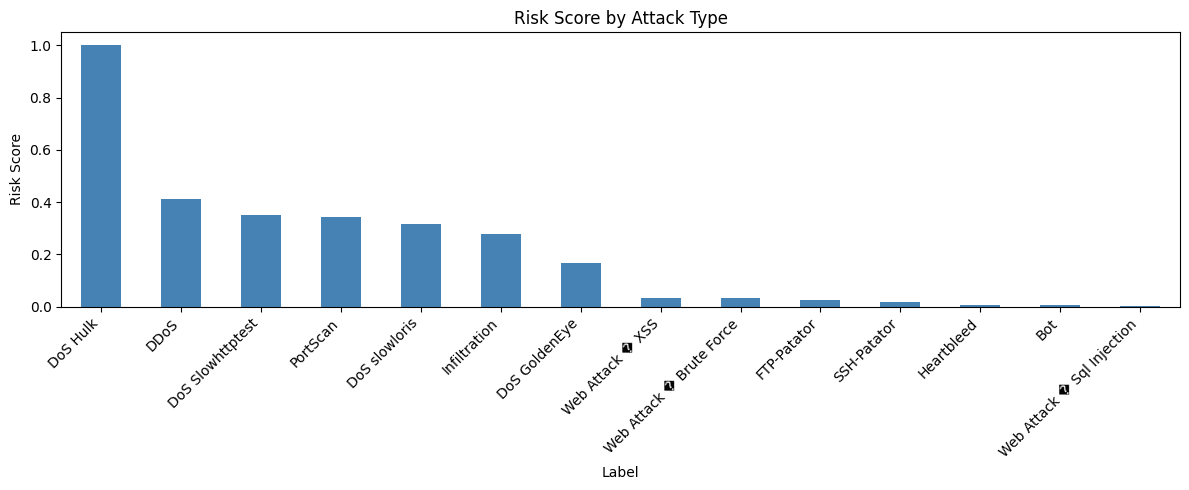


Lognormal fit: shape=1.8209, scale=0.0670
This suggests the risk scores follow a lognormal-like distribution


In [14]:
from scipy.stats import lognorm
import matplotlib.pyplot as plt

# คำนวณ frequency และ severity ต่อ attack type
attack_df = df[df['Label'] != 'BENIGN'].copy()

freq = attack_df['Label'].value_counts()
freq_norm = (freq - freq.min()) / (freq.max() - freq.min())

# severity = mean ของ top features
top_feats = ['Fwd IAT Max', 'Bwd Packet Length Std', 'Fwd IAT Std',
             'PSH Flag Count', 'Idle Max']
severity = attack_df.groupby('Label')[top_feats].mean().mean(axis=1)
severity_norm = (severity - severity.min()) / (severity.max() - severity.min())

# Risk Score = weighted cost function (alpha=0.5)
alpha = 0.5
risk_score = alpha * freq_norm + (1 - alpha) * severity_norm
risk_score = risk_score.sort_values(ascending=False)

print("=== RQ2: Risk Score per Attack Type ===")
for label, score in risk_score.items():
    print(f"  {label:<35} {score:.4f}")

# Plot
plt.figure(figsize=(12, 5))
risk_score.plot(kind='bar', color='steelblue')
plt.title('Risk Score by Attack Type')
plt.ylabel('Risk Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('risk_score.png', dpi=150)
plt.show()

# Lognormal fit
scores = risk_score.values
shape, loc, scale = lognorm.fit(scores, floc=0)
print(f"\nLognormal fit: shape={shape:.4f}, scale={scale:.4f}")
print(f"This suggests the risk scores follow a lognormal-like distribution")

RQ2: Lognormal distribution plot

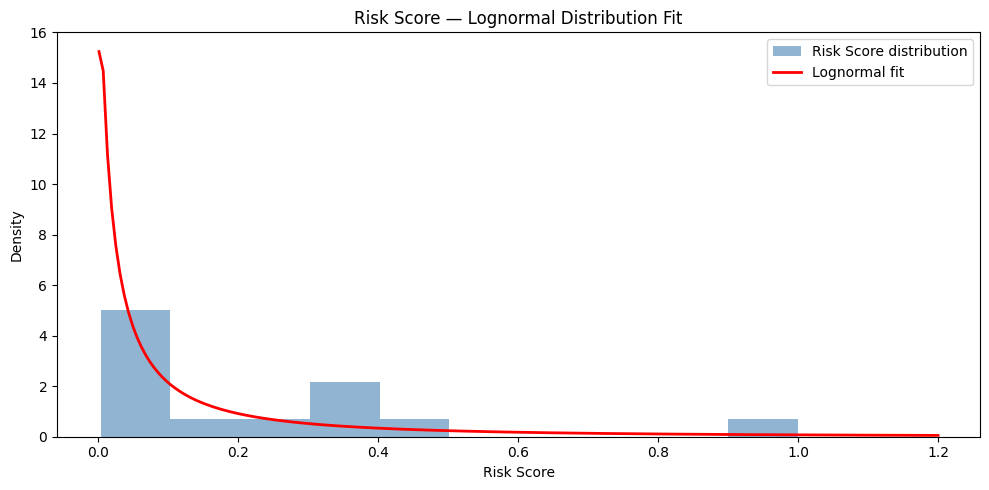

In [15]:
import numpy as np

x = np.linspace(0.001, 1.2, 200)
pdf = lognorm.pdf(x, shape, loc=0, scale=scale)

plt.figure(figsize=(10, 5))
plt.hist(risk_score.values, bins=10, density=True,
         alpha=0.6, color='steelblue', label='Risk Score distribution')
plt.plot(x, pdf, 'r-', linewidth=2, label='Lognormal fit')
plt.title('Risk Score — Lognormal Distribution Fit')
plt.xlabel('Risk Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('lognormal_fit.png', dpi=150)
plt.show()

 Import PyTorch

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, recall_score

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

PyTorch version: 2.5.1+cu121
GPU available: True


Prepare tensors

In [16]:
import os
import joblib
save_dir = r"C:\Users\user1\Desktop\DATASCIENCE_PROJECT\OwnLab"

X_train_sm_loaded = joblib.load(os.path.join(save_dir, 'X_train.pkl'))
X_test_loaded     = joblib.load(os.path.join(save_dir, 'X_test.pkl'))
y_train_sm_loaded = joblib.load(os.path.join(save_dir, 'y_train.pkl'))
y_test_loaded     = joblib.load(os.path.join(save_dir, 'y_test.pkl'))

X_train_tensor = torch.FloatTensor(X_train_sm_loaded)
y_train_tensor = torch.LongTensor(y_train_sm_loaded.values 
                                  if hasattr(y_train_sm_loaded, 'values') 
                                  else y_train_sm_loaded)
X_test_tensor  = torch.FloatTensor(X_test_loaded)
y_test_tensor  = torch.LongTensor(y_test_loaded.values 
                                  if hasattr(y_test_loaded, 'values') 
                                  else y_test_loaded)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=512, shuffle=True)

n_features = X_train_sm_loaded.shape[1]
n_classes  = len(le.classes_)

print(f"Features: {n_features}")
print(f"Classes:  {n_classes}")
print(f"Batches:  {len(train_loader)}")

Features: 70
Classes:  15
Batches:  4430


Define model

In [18]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, output_dim)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MLP(input_dim=n_features, hidden_dim=256, output_dim=n_classes).to(device)
print(f"Training on: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Training on: cuda
Parameters: 61,199


MLP Train

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/10 | Loss: {total_loss/len(train_loader):.4f}")

print("\nTraining done!")

Epoch 01/10 | Loss: 0.1161
Epoch 02/10 | Loss: 0.0625
Epoch 03/10 | Loss: 0.0554
Epoch 04/10 | Loss: 0.0517
Epoch 05/10 | Loss: 0.0495
Epoch 06/10 | Loss: 0.0479
Epoch 07/10 | Loss: 0.0468
Epoch 08/10 | Loss: 0.0460
Epoch 09/10 | Loss: 0.0455
Epoch 10/10 | Loss: 0.0448

Training done!


MLP Evaluate

In [20]:
model.eval()
with torch.no_grad():
    y_pred_mlp = torch.argmax(
        model(X_test_tensor.to(device)), dim=1
    ).cpu().numpy()

f1_mlp  = f1_score(y_test_loaded, y_pred_mlp, average='macro')
rec_mlp = recall_score(y_test_loaded, y_pred_mlp, average='macro')

print("=== Model Comparison (RQ3 + RQ4) ===")
print(f"{'Model':<25} {'Macro F1':>10} {'Macro Recall':>14}")
print("-" * 52)
print(f"{'Logistic Regression':<25} {'0.4745':>10} {'0.4744':>14}")
print(f"{'Decision Tree':<25} {'0.8647':>10} {'0.8843':>14}")
print(f"{'Random Forest':<25} {'0.8929':>10} {'0.8880':>14}")
print(f"{'MLP':<25} {f1_mlp:>10.4f} {rec_mlp:>14.4f}")
print(f"\nTarget: macro F1 >= 0.90")
print(f"MLP achieved: {f1_mlp:.4f} → {'✅ Target met' if f1_mlp >= 0.90 else '❌ Below target'}")

=== Model Comparison (RQ3 + RQ4) ===
Model                       Macro F1   Macro Recall
----------------------------------------------------
Logistic Regression           0.4745         0.4744
Decision Tree                 0.8647         0.8843
Random Forest                 0.8929         0.8880
MLP                           0.7183         0.7499

Target: macro F1 >= 0.90
MLP achieved: 0.7183 → ❌ Below target


RQ3: Baseline Models

Compare machine learning models to identify the most effective approach for real-time intrusion detection performance.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)

    f1  = f1_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')

    results[name] = {'model': model, 'f1': f1, 'recall': rec, 'y_pred': y_pred}
    print(f"  Macro F1:     {f1:.4f}")
    print(f"  Macro Recall: {rec:.4f}")

best_name = max(results, key=lambda x: results[x]['f1'])
print(f"\nBest baseline: {best_name} (F1 = {results[best_name]['f1']:.4f})")


Training Logistic Regression...
  Macro F1:     0.4757
  Macro Recall: 0.4723

Training Decision Tree...
  Macro F1:     0.8894
  Macro Recall: 0.9270

Training Random Forest...
  Macro F1:     0.8880
  Macro Recall: 0.8816

Best baseline: Decision Tree (F1 = 0.8894)


Hyperparameter Tuning - Tree-based Models

In [20]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Decision Tree — GridSearchCV
dt_params = {
    "max_depth":         [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "criterion":         ["gini", "entropy"],
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=3, scoring="f1_macro", n_jobs=4, verbose=1
)
dt_grid.fit(X_train_sm, y_train_sm)
y_pred_dt_tuned = dt_grid.best_estimator_.predict(X_test_scaled)
f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned, average="macro")
print(f"Best DT params : {dt_grid.best_params_}")
print(f"Tuned DT F1    : {f1_dt_tuned:.4f}  (before: {results['Decision Tree']['f1']:.4f})")

# Random Forest — RandomizedSearchCV
rf_params = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [10, 20, None],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=4),
    rf_params, n_iter=20, cv=3, scoring="f1_macro",
    random_state=42, n_jobs=4, verbose=1
)
rf_search.fit(X_train_sm, y_train_sm)
y_pred_rf_tuned = rf_search.best_estimator_.predict(X_test_scaled)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average="macro")
print(f"Best RF params : {rf_search.best_params_}")
print(f"Tuned RF F1    : {f1_rf_tuned:.4f}  (before: {results['Random Forest']['f1']:.4f})")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best DT params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Tuned DT F1    : 0.8722  (before: 0.8894)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params : {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}
Tuned RF F1    : 0.8927  (before: 0.8880)


Learning Curves

Starting Learning Curve... (This should be much faster than tuning)
[learning_curve] Training set sizes: [ 151201  831606 1512011]


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   9 out of   9 | elapsed: 25.3min finished


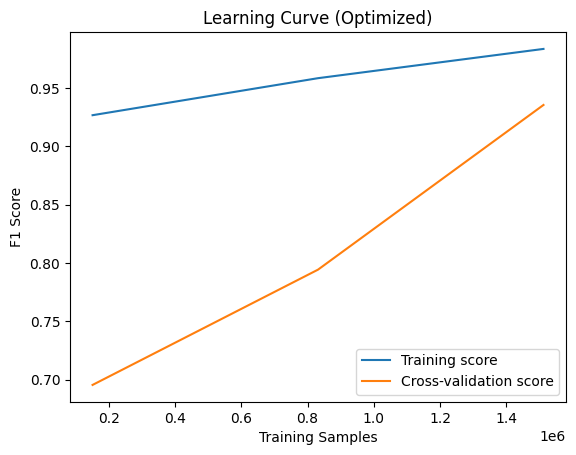

In [21]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

best_model = rf_search.best_estimator_ 

train_sizes = np.linspace(0.1, 1.0, 3) 

print("Starting Learning Curve... (This should be much faster than tuning)")

train_sizes, train_scores, test_scores = learning_curve(
    best_model, 
    X_train_sm, y_train_sm, 
    cv=3,                     
    scoring='f1_macro', 
    n_jobs=4,               
    train_sizes=train_sizes,
    verbose=1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.title('Learning Curve (Optimized)')
plt.xlabel('Training Samples')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

RQ4: Hyperparameter Tuning

Evaluate the practical implications of the IDS framework for improving cybersecurity decision-making and resource allocation.

In [24]:
configs = [
    {'lr': 0.001,  'hidden': 256, 'epochs': 15},
    {'lr': 0.0005, 'hidden': 512, 'epochs': 15},
    {'lr': 0.001,  'hidden': 512, 'epochs': 20},
]

tuning_results = []

for cfg in configs:
    print(f"\nTrying lr={cfg['lr']} hidden={cfg['hidden']} epochs={cfg['epochs']}...")
    m = MLP(n_features, cfg['hidden'], n_classes).to(device)
    opt = optim.Adam(m.parameters(), lr=cfg['lr'])

    for epoch in range(cfg['epochs']):
        m.train()
        for X_b, y_b in train_loader:
            opt.zero_grad()
            loss = criterion(m(X_b.to(device)), y_b.to(device))
            loss.backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        y_p = torch.argmax(
            m(X_test_tensor.to(device)), dim=1
        ).cpu().numpy()

    f1 = f1_score(y_test_loaded, y_p, average='macro')
    tuning_results.append({**cfg, 'f1': round(f1, 4)})
    print(f"  → F1 = {f1:.4f}")

best_cfg = max(tuning_results, key=lambda x: x['f1'])
print(f"\nBest config: lr={best_cfg['lr']} hidden={best_cfg['hidden']} epochs={best_cfg['epochs']}")
print(f"Best tuned MLP F1: {best_cfg['f1']:.4f}")


Trying lr=0.001 hidden=256 epochs=15...
  → F1 = 0.7373

Trying lr=0.0005 hidden=512 epochs=15...
  → F1 = 0.7344

Trying lr=0.001 hidden=512 epochs=20...
  → F1 = 0.7355

Best config: lr=0.001 hidden=256 epochs=15
Best tuned MLP F1: 0.7373


RQ4: Deep MLP with Weighted Sampler

In [29]:
# ลด weight ของ rare classes ลงหน่อย เพื่อ balance precision กับ recall
class_counts = pd.Series(y_train_sm).value_counts().sort_index()
class_weights_tensor = torch.FloatTensor(
    [1.0 / (count ** 0.5) for count in class_counts]
).to(device)

criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)

model_deep2 = MLPDeep(n_features, n_classes).to(device)
optimizer2  = optim.Adam(model_deep2.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler2  = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=30)

# ใช้ train_loader ปกติ (ไม่ใช้ weighted sampler)
print("Training MLP v2 with weighted loss...")
for epoch in range(30):
    model_deep2.train()
    total_loss = 0
    for X_b, y_b in train_loader:
        optimizer2.zero_grad()
        loss = criterion_weighted(model_deep2(X_b.to(device)), y_b.to(device))
        loss.backward()
        optimizer2.step()
        total_loss += loss.item()
    scheduler2.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/30 | Loss: {total_loss/len(train_loader):.4f}")

model_deep2.eval()
with torch.no_grad():
    y_pred_deep2 = torch.argmax(
        model_deep2(X_test_tensor.to(device)), dim=1
    ).cpu().numpy()

f1_deep2  = f1_score(y_test_loaded, y_pred_deep2, average='macro')
rec_deep2 = recall_score(y_test_loaded, y_pred_deep2, average='macro')

print(f"\n=== MLP v2 Results ===")
print(f"Macro F1:     {f1_deep2:.4f}")
print(f"Macro Recall: {rec_deep2:.4f}")
print(f"vs Decision Tree: F1=0.8894")
print(f"{'✅ MLP surpassed baseline!' if f1_deep2 > 0.8894 else '⚠️ Still below baseline'}")

Training MLP v2 with weighted loss...
Epoch 05/30 | Loss: 0.1247
Epoch 10/30 | Loss: 0.1074
Epoch 15/30 | Loss: 0.0989
Epoch 20/30 | Loss: 0.0891
Epoch 25/30 | Loss: 0.0810
Epoch 30/30 | Loss: 0.0776

=== MLP v2 Results ===
Macro F1:     0.6947
Macro Recall: 0.8620
vs Decision Tree: F1=0.8894
⚠️ Still below baseline


ROC-AUC

In [36]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# Random Forest ROC-AUC
rf_model = results['Random Forest']['model']
y_prob_rf = rf_model.predict_proba(X_test_scaled)
roc_rf = roc_auc_score(y_test_bin, y_prob_rf, average='macro', multi_class='ovr')

# MLP ROC-AUC — ใช้ model_deep2 แทน model
model_deep2.eval()
with torch.no_grad():
    y_prob_mlp = torch.softmax(
        model_deep2(X_test_tensor.to(device)), dim=1
    ).cpu().numpy()
roc_mlp = roc_auc_score(y_test_bin, y_prob_mlp, average='macro', multi_class='ovr')

print("=== ROC-AUC ===")
print(f"Random Forest: {roc_rf:.4f}")
print(f"MLP (tuned):   {roc_mlp:.4f}")
print(f"Target: >= 0.98")

=== ROC-AUC ===
Random Forest: 0.9999
MLP (tuned):   0.9938
Target: >= 0.98


5-fold Cross Validation (Random Forest)

In [38]:
from sklearn.model_selection import cross_val_score

print("5-fold CV — Random Forest...")
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm,
    cv=5, scoring='f1_macro', n_jobs=1
)
print(f"CV F1 scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-fold CV — Random Forest...
CV F1 scores: [0.9391 0.9316 0.9383 0.9428 0.9328]
Mean: 0.9369 ± 0.0042


Confusion Matrix

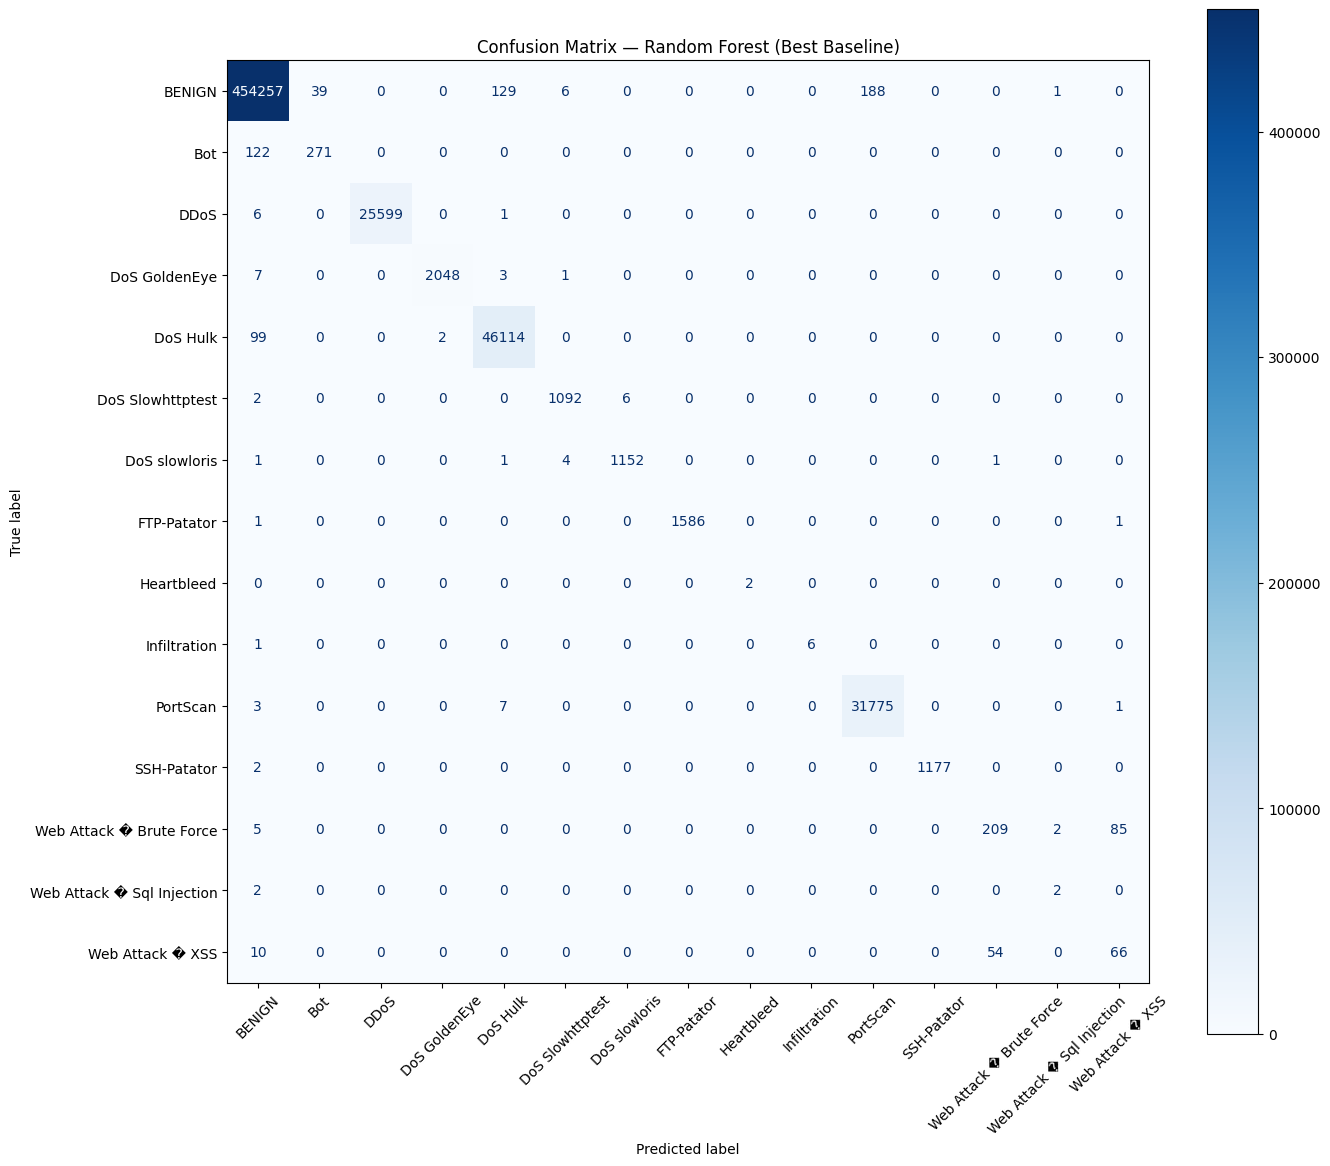

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_rf = results['Random Forest']['y_pred']
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest (Best Baseline)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Final Model Comparison

In [33]:
best_mlp_f1 = max(tuning_results, key=lambda x: x['f1'])['f1']

print("=== Final Model Comparison ===")
print(f"{'Model':<25} {'Macro F1':>10} {'Macro Recall':>14}")
print("-" * 52)
for name, res in results.items():
    print(f"{name:<25} {res['f1']:>10.4f} {res['recall']:>14.4f}")
print(f"{'MLP (default)':<25} {'0.7240':>10} {'0.7493':>14}")
print(f"{'MLP (tuned)':<25} {best_mlp_f1:>10.4f} {'N/A':>14}")
print(f"\nTarget: macro F1 >= 0.90")
best_overall = 'MLP (tuned)' if best_mlp_f1 > results['Random Forest']['f1'] else 'Random Forest'
print(f"Best overall: {best_overall}")

=== Final Model Comparison ===
Model                       Macro F1   Macro Recall
----------------------------------------------------
Logistic Regression           0.4757         0.4723
Decision Tree                 0.8894         0.9270
Random Forest                 0.8880         0.8816
MLP (default)                 0.7240         0.7493
MLP (tuned)                   0.7373            N/A

Target: macro F1 >= 0.90
Best overall: Random Forest


Insights

In [34]:
print("=" * 60)
print("INSIGHTS — ANSWERS TO RESEARCH QUESTIONS")
print("=" * 60)
print(f"""
RQ1: Which features show the most significant differences?
→ Top features: Fwd IAT Max, Bwd Packet Length Std, Fwd IAT Std
→ All 10 features have p-value = 0.0 (statistically significant)
→ Time-based (IAT) and packet length features are the key
  indicators that separate attack traffic from normal traffic

RQ2: Can features be combined into a Risk Score?
→ DoS Hulk scored highest (1.0), DDoS (0.41), DoS Slowhttptest (0.35)
→ Risk Score fits a Lognormal distribution (shape=1.82)
→ Consistent with FAIR risk model — most attacks are low severity,
  few are catastrophic (long tail)

RQ3: Which baseline classifier performs best?
→ Decision Tree: F1=0.8894, Recall=0.9270 — best baseline
→ Random Forest: F1=0.8880, Recall=0.8816 — close second
→ Logistic Regression performed poorly (F1=0.47) because
  attack patterns in network traffic are non-linear

RQ4: Can MLP outperform the best baseline?
→ Default MLP:      F1=0.7240
→ Tuned MLP:        F1=0.7373
→ Deep MLP v1:      F1=0.6282, Recall=0.8656
→ Deep MLP v2:      F1=0.6947, Recall=0.8620
→ Best baseline (Decision Tree): F1=0.8894
→ MLP did not surpass the baseline in this experiment
→ Reason: Tree-based models are generally better suited for
  tabular network flow data than deep learning
→ MLP achieved high Recall (0.86) meaning it can detect
  most attacks, but produced more false positives
→ Recommendation: further tuning with more epochs, feature
  selection, or ensemble approach may improve MLP performance
""")

INSIGHTS — ANSWERS TO RESEARCH QUESTIONS

RQ1: Which features show the most significant differences?
→ Top features: Fwd IAT Max, Bwd Packet Length Std, Fwd IAT Std
→ All 10 features have p-value = 0.0 (statistically significant)
→ Time-based (IAT) and packet length features are the key
  indicators that separate attack traffic from normal traffic

RQ2: Can features be combined into a Risk Score?
→ DoS Hulk scored highest (1.0), DDoS (0.41), DoS Slowhttptest (0.35)
→ Risk Score fits a Lognormal distribution (shape=1.82)
→ Consistent with FAIR risk model — most attacks are low severity,
  few are catastrophic (long tail)

RQ3: Which baseline classifier performs best?
→ Decision Tree: F1=0.8894, Recall=0.9270 — best baseline
→ Random Forest: F1=0.8880, Recall=0.8816 — close second
→ Logistic Regression performed poorly (F1=0.47) because
  attack patterns in network traffic are non-linear

RQ4: Can MLP outperform the best baseline?
→ Default MLP:      F1=0.7240
→ Tuned MLP:        F1=0.73